(sec:xray)=
# X-ray spectroscpies

VeloxChem provides access to a range of X‑ray spectroscopies by combining density‑functional theory with response theory techniques that enable the description of core‑level excitations and their characteristic spectral signatures. These methods allow the simulation of X‑ray absorption, emission, and related core‑level properties, thereby enabling chemically intuitive interpretation of spectral features. For a comprehensive review of theoretical approaches to X‑ray spectroscopies, see {cite}`norman_cr_2018`.

The ESCA molecule, ethyl trifluoroacetate (CF₃–CO–O–CH₂–CH₃), became historically important in X‑ray and photoelectron spectroscopies because its C 1s photoelectron spectrum displays four well‑separated and chemically distinct carbon binding energies, spanning more than 8 eV—a uniquely clear demonstration of chemical shifts arising from different charge environments at individual atomic sites. This spectrum rapidly became the pedagogical showcase for ESCA (Electron Spectroscopy for Chemical Analysis) following Kai Siegbahn’s development of high‑resolution photoelectron spectroscopy in the 1960s, and it has since served as a benchmark for both experimental methodology and theoretical modeling of core‑level shifts. The molecule continues to be used in modern X‑ray and photoelectron studies as a canonical reference system to illustrate how core‑level binding energies encode local electronic structure and substituent effects, linking directly to the foundational ESCA work recognized in Siegbahn’s 1981 Nobel Prize.

In [8]:
import veloxchem as vlx 

molecule = vlx.Molecule.read_xyz_string("""13
b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

molecule.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

(sec:xps)=
## XPS


(sec:nexafs)=
## NEXAFS

NEXAFS (or XANES) spectra can be calculated with the CPP solver by choosing the range of frequencies to the near ionization edge of the element you wish to probe. In terms of choice of functional, the version of the CAM-B3LYP functional with 100% exchange in the asymtotic limit has been shown in a comprehensive benchmark study to perform particularly well {cite}`fransson_xaboom_2021`.

**Python script**

In [6]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

cpp_drv = vlx.ComplexResponse()
cpp_drv.frequencies = np.arange(10.1, 10.4, 0.0025)
cpp_drv.property = "absorption"

cpp_results = cpp_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

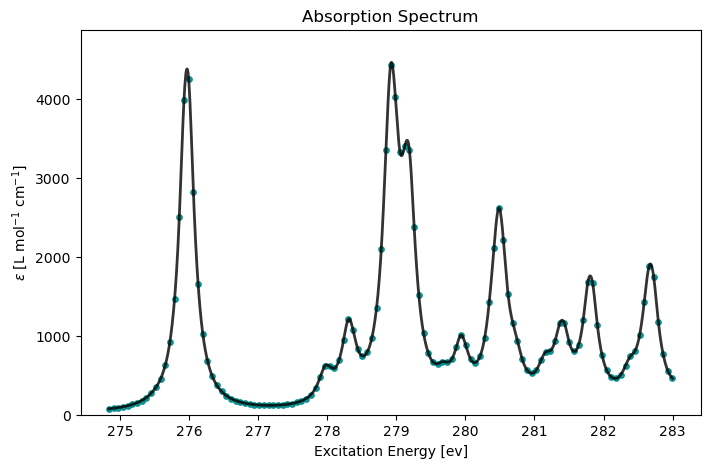

In [8]:
cpp_drv.plot(cpp_results, x_unit="eV")

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: absorption (cpp)
# frequency region (and resolution)
frequencies: 10.1-10.4 (0.0025)
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

Please refer to the [keyword list](#sec:cpp-keywords) for a complete set of options.

(sec:rixs)=
## RIXS